In [1]:
import numpy as np
import sys 
import xarray as xr
import time

np.warnings.filterwarnings('ignore')

In [3]:
'''The script was copied from fwi_NRCanCFS.py sent by Jack C 2022-07-22
   
   Author: Konstantinos Menelaou

Modification:
     2021-Apr. Jack C
     2022-Aug. Liz Ramsey 
                    - added comments 
                    - added lat adjustment of DMC to match fortran code
                    - added fbp_mod to isi in keeping with R code
                    - added lat_cutoff for consistency with R code 

'''

'The script was copied from fwi_NRCanCFS.py sent by Jack C 2022-07-22\n   \n   Author: Konstantinos Menelaou\n\nModification:\n     2021-Apr. Jack C\n     2022-Aug. Liz Ramsey \n                    - added comments \n                    - added lat adjustment of DMC to match fortran code\n                    - added fbp_mod to isi in keeping with R code\n                    - added lat_cutoff for consistency with R code \n\n'

In [8]:
import os

direc = '/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/'

for scen in ['HPB','HPB_NAT']:
    for num in range(1,101):  
        num_string = '0' + str(num) if num > 9 else '00' + str(num)                                                             
        if num == 100: 
            num_string = '100'  
            
        os.system('mv \"'+direc+'FWI_'+scen+'_m'+num_string+' .nc\" '+direc+'FWI_'+scen+'_m'+num_string+'.nc' )
        #print('mv \"'+direc+'FWI_'+scen+'_m'+num_string+' .nc\" '+direc+'FWI_'+scen+'_m'+num_string+'.nc' )

In [5]:
old = xr.open_dataset("/nesi/project/niwa00015/queenle/data/fire/d4pdf/testing_hr_v_day_pr/d4pdf_FWI_daily_pr.nc")
new = xr.open_dataset("/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/FWI_HPB_m001 .nc")
other = xr.open_dataset("/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/FWI_HPB_m078 .nc")

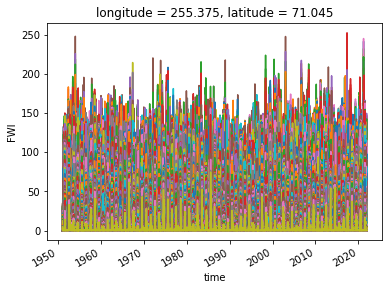

In [18]:
for lat in new.latitude:
    for lon in new.longitude:
        cell = new.sel(latitude=lat,longitude=lon).FWI
        if True in np.isnan(cell.values):
            continue
        cell.plot()

In [9]:
other = xr.open_dataset("/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/FWI_HPB_NAT_m001 .nc")

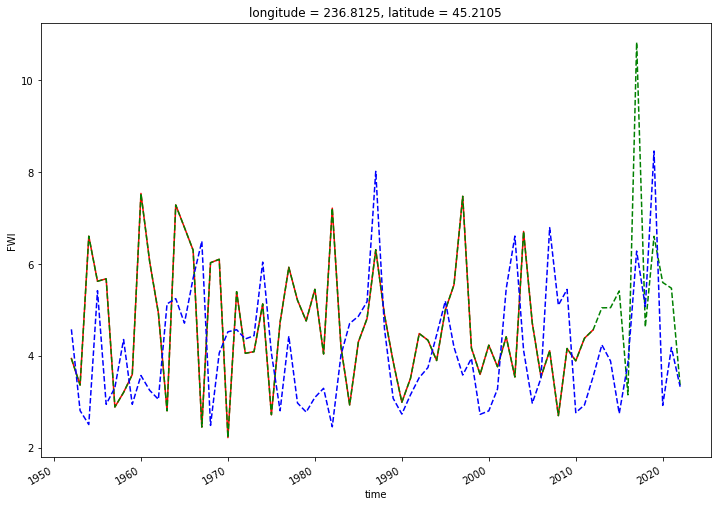

In [10]:
#import matplotlib.pyplot as plt

axs,fig = plt.subplots(figsize=(12,8))

old.FWI.sel(latitude=45,longitude=237-360,method='nearest').resample(time='A').mean().plot(c='r')
new.FWI.sel(latitude=45,longitude=237,method='nearest').resample(time='A').mean().plot(c='g',linestyle='--')
other.FWI.sel(latitude=45,longitude=237,method='nearest').resample(time='A').mean().plot(c='blue',linestyle='--')

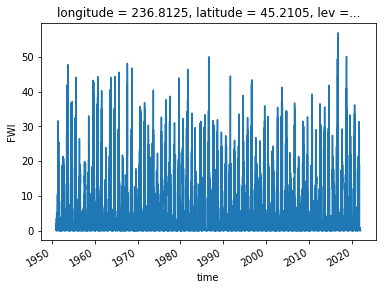

In [29]:
ds.FWI.sel(latitude=45,longitude=237,method='nearest').plot()

In [31]:
test_vals = test.FWI.sel(latitude=45,longitude=237,method='nearest').values
new_vals = ds.FWI.sel(latitude=45,longitude=237,method='nearest').values

In [32]:
test_vals

array([[3.86714107],
       [3.27360105],
       [3.50548041],
       ...,
       [0.00783455],
       [0.02298181],
       [0.00797612]])

In [33]:
new_vals

array([[3.29611793e+00],
       [2.20917903e+00],
       [1.67785627e+00],
       ...,
       [3.37645561e-02],
       [1.16878665e-04],
       [7.81774106e-09]])

In [11]:
ds = xr.open_dataset("/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/inputs/HPB/FWI_inputs_HPB_m001_1951-2021.nc")

ds = ds.rename({'lat':'latitude','lon':'longitude'})

fwi_arr = rasterFWI(ds)




348.5686047077179


<xarray.Dataset>
Dimensions:    (latitude: 92, lev: 1, longitude: 59, time: 25933)
Coordinates:
  * time       (time) datetime64[ns] 1951-01-01 1951-01-02 ... 2021-12-31
  * longitude  (longitude) float64 222.8 223.3 223.9 224.4 ... 254.2 254.8 255.4
  * latitude   (latitude) float64 19.94 20.5 21.06 21.62 ... 69.92 70.48 71.05
  * lev        (lev) float64 1e+03
Data variables:
    precipi    (time, lev, latitude, longitude) float64 ...
    ta         (time, lev, latitude, longitude) float32 ...
    rha        (time, lev, latitude, longitude) float32 ...
    wind       (time, lev, latitude, longitude) float32 ...
    FWI        (time, lev, latitude, longitude) float64 nan nan ... 0.04313

In [14]:
ds["FWI"]=(['time', 'lev','latitude', 'longitude'],  fwi_arr)


In [12]:
FWI_da = ds.drop(['tp','t2m','rh','wind'])
FWI_da.to_netcdf("/nesi/project/niwa00015/queenle/data/fire/d4pdf/testing_hr_v_day_pr/d4pdf_FWI_hrly_pr.nc")

In [13]:
ds = xr.open_dataset("/nesi/project/niwa00015/queenle/data/fire/d4pdf/testing_hr_v_day_pr/d4pdf_FWI_inputs_daily_pr.nc")

ds = ds.rename({'lat':'latitude','lon':'longitude'})

fwi_arr = rasterFWI(ds)




226.4007387161255


In [14]:
ds["FWI"]=(['time', 'lev','latitude', 'longitude'],  fwi_arr)
FWI_da = ds.drop(['tp','t2m','rh','wind'])
FWI_da.to_netcdf("/nesi/project/niwa00015/queenle/data/fire/d4pdf/testing_hr_v_day_pr/d4pdf_FWI_daily_pr.nc")

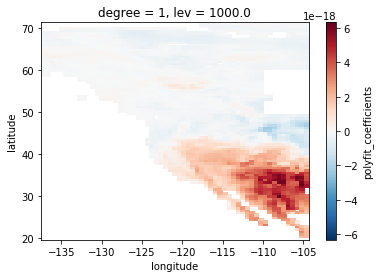

In [20]:
d4pdf_poly_fit = ds.FWI.polyfit(dim='time',deg=1,skipna=True)
d4pdf_poly_fit.sel(degree=1).polyfit_coefficients.plot()#(vmin=-1.5e-17,vmax=1.5e-17,cmap='RdBu_r')


In [16]:
ds.FWI.isel(time=slice(0,365)).mean('time').plot()

In [3]:
'''
MAIN PROGRAM
'''



def rasterFWI(ds):
    
    lat = np.array([[lat]*len(ds.longitude.values) for lat in ds.latitude.values])

    mask = np.isnan(ds.isel(time=0).ta.values)
    prev_ffmc = np.where(mask, np.nan, 85)
    prev_dmc = np.where(mask, np.nan, 6)
    prev_dc = np.where(mask, np.nan, 15)

    #count = 0
    t0 = time.time()

    array_list = []
    for day in ds.time:


        day_ds = ds.sel(time=day)
        month = int(day.dt.month)

        (T, RH, U, PR) = flatten_inputs(day_ds)

        ffmc = FFMCcalc(prev_ffmc, T, RH, U, PR)
        dmc = DMCcalc(prev_dmc, T, RH, PR, month, lat, None, lat_method = 'bands')
        dc = DCcalc(prev_dc, T, PR, month, lat, lat_cutoff = 20)

        isi = ISIcalc(ffmc, U)
        bui = BUIcalc(dmc, dc)

        fwi = FWIcalc(isi, bui)

        prev_ffmc = ffmc
        prev_dmc = dmc
        prev_dc = dc

        array_list.append(fwi)

        #count += 1

    t1 = time.time()
    total = t1-t0
    print(total)

    fwi_arr = np.stack(array_list)
    
    return(fwi_arr)

In [4]:
def flatten_inputs(data_input): 
    """ ensures inputs to FWI calc's are flat 
    
    
    Args:
        data: (xarray dataset) for forecast time, contains variables:
                T (float 32): surface temp (deg C)
                RH (float 32): surface relative humidity (%)
                PR (floate 32): daily precip (mm)
                U (floate 32): 10m wind speed (km/hr)
                    Coordinates: 
                    time: matching forecast_times    Returns:
    Returns:
        T (1D np.array) surface temp (degC)
        RH (1D np.array) relative humidity (%)
        U (1D np.array) wind speed (m/s)
        PR (1D np.array) accumulated daily precip (mm)
    """
    T = np.ravel(data_input.ta.values)
    RH = np.ravel(data_input.rha.values)
    RH = np.where(RH>100, 100, RH)
    U = np.ravel(data_input.wind.values)
    PR = np.ravel(data_input.precipi.values)
    return(T, RH, U, PR)


In [5]:
def FFMCcalc(ffmc0, T, RH, U, P):
    """ calculates fine fuel moisture code
    
    Equations and FORTRAN program for the Canadian Forest Fire
    Weather Index System. 1985. Van Wagner, C.E.; Pickett, T.L.
    Canadian Forestry Service, Petawawa National Forestry
    Institute, Chalk River, Ontario. Forestry Technical Report 33. 18 p.
    
    Args:
        self (object): class of weather inputs (T,RH,U,P) as above
        ffmc0 (np.array, float): yesterdays fine fuel moisture code for initialization, same shape as self variables
    Returns:
        ffmc (np.array, float) calculated fine fuel moisture code for current day 
    """
    shape = ffmc0.shape   
    ffmc0 = ffmc0.flatten()

    mask = np.isnan(ffmc0)
    rf = np.where(mask, np.nan, 0)
    ew = np.where(mask, np.nan, 0)
    kl = np.where(mask, np.nan, 0)
    kw = np.where(mask, np.nan, 0)
    m = np.where(mask, np.nan, 0)
    
    # Eq 1
    mo = np.array((147.27723*(101.0 - ffmc0))/(59.5 + ffmc0))
    
    # Eq 2: rain reduction to allow for loss in overhead canopy
    ind = np.where(P > 0.5)
    rf[ind] = P[ind] - 0.5

    # Eq 3a and 3b
    ind = np.where( (P > 0.5) & (mo > 150.0) )
    mo[ind] = (mo[ind]+42.5*rf[ind]*np.exp(-100.0/(251.0-mo[ind]))*(1.0 - np.exp(-6.93/rf[ind]))) \
                                + (.0015*(mo[ind] - 150.0)**2)*np.sqrt(rf[ind])

    ind = np.where( (P > 0.5) & (mo <= 150.0) )
    mo[ind] = mo[ind]+42.5*rf[ind]*np.exp(-100.0/(251.0-mo[ind]))* \
                    (1.0 - np.exp(-6.93/rf[ind]))

    # cap moisture content at 250% as real moisture content of pine litter has a max of about 250%
    ind = np.where( (P > 0.5) & (mo > 250.0) )
    mo[ind] = 250.0

    # Eq 4 Equilibrium moisture content from drying
    ed = .942*(RH**.679) + (11.0*np.exp((RH-100.0)/10.0))+0.18*(21.1-T) \
            *(1.0 - 1.0/np.exp(.1150 * RH))
    # Eq 5 Equilibrium moisture content from wettin
    ind = np.where(mo < ed)
    ew[ind] = .618*(RH[ind]**.753) + (10.0*np.exp((RH[ind]-100.0)/10.0))\
                + .18*(21.1-T[ind])*(1.0 - 1.0/np.exp(.115 * RH[ind]))

    # Eq 6a log drying rate at the normal temp of 21.1C
    ind = np.where( (mo < ed) & (mo <= ew) )
    kl[ind] = .424*(1.0-((100.0-RH[ind])/100.0)**1.7)+(.0694*np.sqrt(U[ind])) \
                    *(1.0 - ((100.0 -RH[ind])/100.0)**8)
    # Eq 6b Effect of temp on drying rate
    kw[ind] = kl[ind] * (.581 * np.exp(.0365 * T[ind]))
    # Eq 8
    m[ind] = ew[ind] - (ew[ind] - mo[ind])/10.0**kw[ind]

    ind = np.where( (mo < ed) & (mo > ew) )
    m[ind] = mo[ind]

    ind = np.where(mo == ed)
    m[ind] = mo[ind]
    # Eq 7a log wetting rate at the normal temp of 21.1C
    ind = np.where(mo > ed)
    kl[ind] =0.424*(1.0-(RH[ind]/100.0)**1.7)+(.0694*np.sqrt(U[ind]))* \
                    (1.0-(RH[ind]/100.0)**8)
    # Eq 7b effect of temp on wetting rate
    kw[ind] = kl[ind] * (.581*np.exp(.0365*T[ind]))
    #Eq 9
    m[ind] = ed[ind] + (mo[ind]-ed[ind])/10.0 ** kw[ind]
    #Eq 10
    ffmc = (59.5 * (250.0 - m)) / (147.2 + m)
    
    #contstraints
    ind = np.where(ffmc > 101.0)
    ffmc[ind] = 101.0
    ind = np.where(ffmc <= 0.0)
    ffmc[ind] = 0.0
    ffmc = np.reshape(ffmc,shape)
    return(ffmc)


In [6]:
def DMCcalc(dmc0, T, RH, P, month, lat, JD, lat_method = 'continuous'):
    """ calculates duff moisture code
    
    Equations and FORTRAN program for the Canadian Forest Fire
    Weather Index System. 1985. Van Wagner, C.E.; Pickett, T.L.
    Canadian Forestry Service, Petawawa National Forestry
    Institute, Chalk River, Ontario. Forestry Technical Report 33. 18 p.
    
    Args:
        self (object): class of weather inputs (T,RH,U,P) as above
        dmc0 (np.array, float): yesterdays duff moisture code for initialization, same shape as self variables
        month (int): numerical month
        lat (np.array, float): latitude (decimal degrees)
        JD (float): julian date
        lat_method (string): one of 'bands', 'none', or 'continuous' defining the type of latitude adjustment to use
        
    Returns:
        dmc (np.array, float) calculated duff moisture code for current day
    """
    shape = dmc0.shape
    dmc0 = dmc0.flatten()
    lat = lat.flatten()

    mask = np.isnan(dmc0)
    pr = np.where(mask, np.nan, 0)
    re = np.where(mask, np.nan, 0)
    Mo = np.where(mask, np.nan, 0)
    b =  np.where(mask, np.nan, 0)
    Mr =  np.where(mask, np.nan, 0)
    K =  np.where(mask, np.nan, 0)
    
    # Adjustment factor the day length  and thus the drying r, based on latitude and month
    if lat_method == 'none':
        # 46N: Canadian standard, latitude >= 30N   (Van Wagner 1987)
        ell01 = [6.5, 7.5, 9, 12.8, 13.9, 13.9, 12.4, 10.9, 9.4, 8, 7, 6]
        Le = ell01[month - 1]
    elif lat_method == 'bands':
        # 46N: Canadian standard, latitude >= 30N   (Van Wagner 1987)
        ell01 = [6.5, 7.5, 9, 12.8, 13.9, 13.9, 12.4, 10.9, 9.4, 8, 7, 6]
        # 20N: For 30 > latitude >= 10
        ell02 = [7.9, 8.4, 8.9, 9.5, 9.9, 10.2, 10.1, 9.7, 9.1, 8.6, 8.1, 7.8]
        # 20S: For -10 > latitude >= -30
        ell03 = [10.1, 9.6, 9.1, 8.5, 8.1, 7.8, 7.9, 8.3, 8.9, 9.4, 9.9, 10.2]
        # 40S: For -30 > latitude
        ell04 = [11.5, 10.5, 9.2, 7.9, 6.8, 6.2, 6.5, 7.4, 8.7, 10, 11.2, 11.8]
        # For latitude near the equator, we simple use a factor of 9 for all months

        Le = np.repeat(ell01[month - 1], lat.shape)
        Le = np.where((lat <= 30) & (lat > 10), ell02[month - 1], Le)
        Le = np.where((lat <= -10) & (lat > -30), ell03[month - 1], Le)
        Le = np.where((lat <= -30) & (lat >= -90), ell04[month - 1], Le)
        Le = np.where((lat <= 10) & (lat > -10), 9, Le)

    elif lat_method == 'continuous':

        E_ecc = 0.01671123
        E_obl   = 23.4334
        E_sidyr = 365.2564
        PIOVER180 = 3.1415926/180.

        latd = np.copy(lat)
        ind = np.where( latd > 60.0)
        latd[ind] = 60.0
        ind = np.where( latd < -60.0)
        latd[ind] = -60.0

        latr = latd * PIOVER180
        alpha = E_obl * PIOVER180
        omega = 360.0 * PIOVER180/E_sidyr
        beta = omega * (JD-80.5) + 2. * E_ecc * (np.sin(JD*omega) - np.sin(80.5 * omega))
        gamma = np.sin(alpha) * np.sin(beta)
        gamma = np.arctan2(gamma/((1-(gamma**2))**0.5), 1.0)

        dla = -1.0 * np.tan(latr) * np.tan(gamma)
        dlb = np.arctan2((1-(dla**2))**0.5, dla)
        dl = dlb * 2./(PIOVER180*15.)
        Le = dl - 3.0
    else:
        print("Latitude adjustmnet methods are 'bands', 'none', or 'continuous'")
        sys.exit(1)
        
    ind = np.where(P <= 1.5)
    pr[ind] = dmc0[ind]

    ind =  np.where(P > 1.5)
    # Eq 11 Net rain amount
    re[ind] = 0.92*P[ind] - 1.27
    # Eq 12
    Mo[ind] = 20. + np.exp(5.6348 - dmc0[ind]/43.43)
    #Eq 13
    ind = np.where( (P> 1.5) & (dmc0 <= 33.0) )
    b[ind] = 100. / (0.5 + 0.3*dmc0[ind])
    ind = np.where( (P > 1.5) & (dmc0 <= 65.0) & (dmc0 > 33.0))  #!#
    b[ind] = 14. - 1.3*np.log(dmc0[ind])
    ind = np.where( (P > 1.5) & (dmc0 > 65.0) )
    b[ind] =  6.2 * np.log(dmc0[ind]) - 17.2
    
    # Eq 14
    ind = np.where(P > 1.5)
    Mr[ind] = Mo[ind] + (1000.*re[ind]) / (48.77 + b[ind]*re[ind])
    # Eq 15
    pr[ind] = 244.72 - 43.43 * np.log(Mr[ind]-20.)
    
    # Eq 16 log drying rate
    ind = np.where(T >= -1.1 )
    K[ind] = 1.894*(T[ind]+1.1) * (100.- RH[ind]) * (Le[ind]*0.000001)
    ind = np.where(T < -1.1 )
    K[ind] = 0.0

    # P constraints
    ind = np.where( pr < 0.0)
    pr[ind] = 0.0

    #dmc
    dmc = pr + 100.0*K
    ind = np.where(dmc <= 0.0)
    dmc[ind] = 0.0
    dmc = np.reshape(dmc, shape)
    return(dmc)


In [7]:
def DCcalc(dc0, T, P, month, lat, lat_cutoff = 20):
    """ calculates drought code
    
    Equations and FORTRAN program for the Canadian Forest Fire
    Weather Index System. 1985. Van Wagner, C.E.; Pickett, T.L.
    Canadian Forestry Service, Petawawa National Forestry
    Institute, Chalk River, Ontario. Forestry Technical Report 33. 18 p.
    
    Args:
        self (object): class of weather inputs (T,RH,U,P) as above
        dc0 (np.array, float): yesterdays drought code for initialization, same shape as self variables
        month (int): numerical month
        lat (np.array, float): latitude (decimal degrees)
        lat_cutoff (float): absolute value of latitude cutoff for daylength adjustments (degrees)
                                - default of 20 degrees recommended, 10 degrees used by CFFDRS R code
    Returns:
        dc (np.array, float) calculated drought code for current day 
    """
    shape = dc0.shape     
    dc0 = dc0.flatten()
    lat = lat.flatten()

    mask = np.isnan(dc0.flatten())
    rd = np.where(mask, np.nan, 0)
    Qo = np.where(mask, np.nan, 0)
    Qr = np.where(mask, np.nan, 0)
    dr = np.where(mask, np.nan, 0)
    Lf = np.where(mask, np.nan, 0)
    V = np.where(mask, np.nan, 0)

    # Day length factor for DC Calculation
    # 20N: North of 20 degrees N
    Lfn = [-1.6,-1.6,-1.6, 0.9, 3.8, 5.8, 6.4, 5.0, 2.4, 0.4,-1.6,-1.6]
    #20S: South of 20 degrees S
    Lfs = [6.4, 5.0, 2.4, 0.4,-1.6,-1.6,-1.6,-1.6,-1.6, 0.9, 3.8, 5.8]
    # Near the equator, we just use 1.4 for all months. (<20 & >-20)
    Lfe = [1.4, 1.4, 1.4, 1.4, 1.4, 1.4, 1.4, 1.4, 1.4, 1.4, 1.4, 1.4]

    t = T
    ind = np.where( lat > lat_cutoff)
    Lf[ind] = Lfn[month -1]
    ind = np.where( lat <= -1* lat_cutoff)
    Lf[ind] = Lfs[month -1]
    ind = np.where( (lat >-1* lat_cutoff) & (lat<= lat_cutoff))
    Lf[ind] = Lfe[month -1]

        # Eq 18 effective rainfall
    ind = np.where( P > 2.8)
    rd[ind] = 0.83*P[ind] - 1.27  #rw in R code
    
        # Eq 19
    Qo[ind] = 800. * np.exp(-dc0[ind]/400.) #smi in R code
    Qr[ind] = Qo[ind] + 3.937*rd[ind]
    dr[ind] = 400.*np.log(800./Qr[ind])

    ind = np.where( (P > 2.8) & (dr > 0.) )
    dc0[ind] = dr[ind]
    ind = np.where( (P > 2.8) & (dr <= 0.) )
    dc0[ind] = 0.0

    #Eq 22: potential evapotranspiration, cap temp at -2.8
    ind = np.where( t < -2.8 )
    V[ind] = Lf[ind]
    ind = np.where( t >= -2.8 )
    V[ind] = (0.36*(t[ind]+2.8) + Lf[ind])
    ind = np.where( V <= 0.0 )
    V[ind] = 0.0

    dc = np.reshape(dc0, shape) + 0.5 * np.reshape(V,shape)
    return(dc)


In [8]:
def ISIcalc(ffmc, U, fbp_mod = False):
    """ calculates initial spread index 
    
    Equations and FORTRAN program for the Canadian Forest Fire
    Weather Index System. 1985. Van Wagner, C.E.; Pickett, T.L.
    Canadian Forestry Service, Petawawa National Forestry
    Institute, Chalk River, Ontario. Forestry Technical Report 33. 18 p.
    
    Args:
        self (object): class of weather inputs (T,RH,U,P) as above
        ffmc (np.array, float): fine fuel moisture code of current day
        fbpMod(True/False) if using the fbp modification at the extreme end
    Returns:
        isi (np.array, float) calculated initial spread index 
    """
    shape = ffmc.shape
    ffmc = ffmc.flatten()
    
    # Eq 10 moisture content
    mo = 147.27723*(101.0-ffmc) / (59.5+ffmc)
    # Eq 24 wind effect
    fw = np.exp(0.05039* U)
    if fbp_mod:
        ind = np.where(U > 0)
        fw[ind] =  12 * (1 - np.exp(-0.0818 * (U - 28)))
    #Eq. 25 - Fine Fuel Moisture
    ff = 19.1152*np.exp(mo*-0.1386) * (1.0+(mo**5.31)/49300000.0)
    isi = ff * fw
    isi = np.reshape(isi, shape)
    return(isi)

In [9]:
def BUIcalc(dmc,dc):
    """ calculates build up index 
    
    Equations and FORTRAN program for the Canadian Forest Fire
    Weather Index System. 1985. Van Wagner, C.E.; Pickett, T.L.
    Canadian Forestry Service, Petawawa National Forestry
    Institute, Chalk River, Ontario. Forestry Technical Report 33. 18 p.
    
    Args:
        self (object): class of weather inputs (T,RH,U,P) as above
        dmc (np.array, float): duff moisture of current day
        dc (np.array, float): drought code of current day
    Returns:
        bui (np.array, float) calculated build up index
    """
    shape = dmc.shape
    dmc = dmc.flatten()
    dc = dc.flatten()

    mask = np.isnan(dc)
    bui = np.where(mask, np.nan, 0)

    np.seterr(divide='ignore', invalid='ignore') #!#
    #Note, if dmc = 0 and dc = 0 there will be division by zero i.e., dmc[ind] + 0.4*dc[ind] = 0#!#
    
    # Eq. 27a
    ind = np.where( dmc <= 0.4*dc)
    bui[ind] = (0.8*dc[ind]*dmc[ind]) / (dmc[ind] + 0.4*dc[ind])
    # Eq. 27b 
    ind = np.where(dmc > 0.4*dc)
    bui[ind] =  dmc[ind]-(1.0-0.8*dc[ind]/(dmc[ind]+0.4*dc[ind]))*(0.92+(0.0114*dmc[ind])**1.7)
    # Constraints
    ind = np.where( bui < 0.0 )
    bui[ind] = 0.0
    bui = np.reshape(bui, shape)
    return(bui)

In [10]:
def FWIcalc( isi, bui):
    
    """ calculates Fire Weather Index
    
    Equations and FORTRAN program for the Canadian Forest Fire
    Weather Index System. 1985. Van Wagner, C.E.; Pickett, T.L.
    Canadian Forestry Service, Petawawa National Forestry
    Institute, Chalk River, Ontario. Forestry Technical Report 33. 18 p.
    
    Args:
        self (object): class of weather inputs (T,RH,U,P) as above
        isi (np.array, float): initial spread index of current day
        bui (np.array, float): build up index of current day
    Returns:
        fwi (np.array, float) calculated fire weather index of current day 
    """
    shape = isi.shape
    isi = isi.flatten()
    bui = bui.flatten()

    mask = np.isnan(isi)
    fwi = np.where(mask, np.nan, 0)
    bb = np.where(mask, np.nan, 0)

    # Eq. 28a & 29
    ind = np.where( bui <= 80.0)
    bb[ind] = 0.1*isi[ind]*(0.626*bui[ind]**0.809 + 2.0)
    # Eq. 28b & 29
    ind = np.where( bui > 80.0)
    bb[ind] = 0.1*isi[ind]*(1000.0/(25. + 108.64/np.exp(0.023*bui[ind])))

    # Eq. 30b
    ind = np.where( bb <= 1.0)
    fwi[ind] = bb[ind]
    # Eq. 30a
    ind = np.where(bb > 1.0)
    fwi[ind] =  np.exp(2.72 *  (0.434*np.log(bb[ind]))**0.647)
    fwi = np.reshape(fwi, shape)
    return(fwi)